In [1]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# defining grid

domain = 2

nx = ny = 31
c = 1
dx = domain / (nx - 1)
dy = domain / (ny - 1)

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

# initial conditions

p = np.zeros((nx, ny))

# boundary conditions
# 1> p = 0 at x = 0 (first index)
p[0, :] = 0

# 2> p = y at x = 2
p[-1, :] = y

# 3> dp/dy = 0 at y = 0 and y = 1
# the absolute golden rule of Neumann boundaries: To force a zero-slope at a wall;
# the boundary points must mirror the values of their immediate inner neighbors.

# at p[i, j] = p[i, j+1] at y = 0 (j = 0)
p[:, 0] = p[:, 1]

# at p[i, j] = p[i, j+1] at y = 2 (j = -1)
p[:, -1] = p[:, -2]

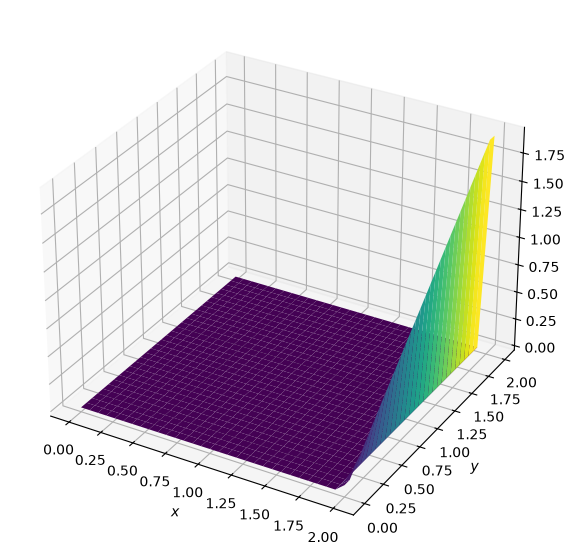

In [3]:
def plot2D(x,y,p):  # define a function for visulizing 2d plot
    fig = plt.figure(figsize = (11,7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    # The '111' means a grid of 1 row and 1 column and this subplot is the first one.
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X,Y,p.T,cmap=cm.viridis)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$');

plot2D(x, y ,p)

In [4]:
def laplace(threshold):
    l1norm = 1
    while l1norm > threshold:
        pn = p.copy()
        p[1:-1, 1:-1] = (((dy)**2 * (pn[:-2, 1:-1] + pn[2:, 1:-1])) + ((dx)**2 * (pn[1:-1, :-2] +
        pn[1:-1, 2:]))) / (2 * ((dx)**2 + (dy)**2))

        # boundary conditions
        p[0, :] = 0
        p[-1, :] = y
        p[:, 0] = p[:, 1]
        p[:, -1] = p[:, -2]
        l1norm = np.sum(np.abs(p - pn)) / np.sum(np.abs(pn))
        
    return p

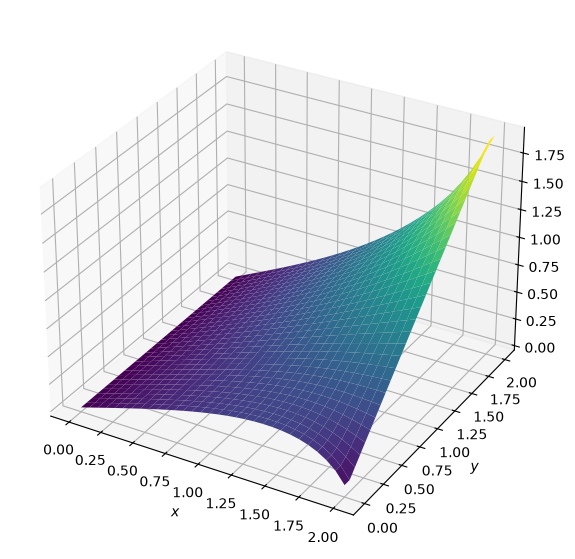

In [5]:
laplace(1e-4)

def plot2D(x, y, p):  # define a function for visulizing 2d plot
    fig = plt.figure(figsize = (11,7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    # The '111' means a grid of 1 row and 1 column and this subplot is the first one.
    X, Y = np.meshgrid(x,y)
    surf = ax.plot_surface(X,Y,p.T,cmap=cm.viridis)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$');

plot2D(x, y, p)